In [27]:
#Import Libraries
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [13]:
df = pd.read_csv('D:\data\Cd\ML\student_performance_dataset.csv')

In [14]:
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [21]:
df.shape

(3000, 32)

In [33]:
df.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [19]:
df.describe

<bound method NDFrame.describe of       student_id  age  gender   city_type  study_hours_per_day  \
0              0   21  Female  Semi-Urban                  3.2   
1              1   19  Female  Semi-Urban                  3.9   
2              2   16  Female       Urban                  4.3   
3              3   19    Male  Semi-Urban                  5.3   
4              4   17  Female       Urban                  4.1   
...          ...  ...     ...         ...                  ...   
2995        2995   22  Female       Rural                  2.4   
2996        2996   19  Female       Urban                  5.2   
2997        2997   23  Female       Rural                  5.9   
2998        2998   17    Male       Urban                  3.9   
2999        2999   16  Female  Semi-Urban                  5.8   

      deep_work_sessions  assignment_completion_rate  attendance_percentage  \
0                      7                         100                     70   
1              

In [ ]:
df.isnull().sum()
#We have missing values in ds, as social_media_hours,focus_score  and sleep_hours

student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_sc

In [22]:
#we have missing values in ds, as social_media_hours,focus_score  and sleep_hours                    
# by using mean imputation we can fill the missing values in these columns

for col in ['social_media_hours','focus_score','sleep_hours']:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Kulde\AppData\Local\Temp\ipykernel_6072\715028060.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [23]:
df.isnull().sum()

student_id                     0
age                            0
gender                         0
city_type                      0
study_hours_per_day            0
deep_work_sessions             0
assignment_completion_rate     0
attendance_percentage          0
social_media_hours             0
doomscrolling_before_sleep     0
notification_distractions      0
ai_tool_usage_hours            0
gaming_hours                   0
stress_level                   0
motivation_level               0
focus_score                    0
procrastination_index          0
mental_state                   0
sleep_hours                    0
caffeine_intake                0
physical_activity_hours        0
internet_quality               0
family_support                 0
financial_stress               0
learning_style                 0
career_goal                    0
productivity_after_midnight    0
revision_efficiency            0
burnout_risk                   0
consistency_score              0
final_exam

Step 3: Distribution of Target Variable

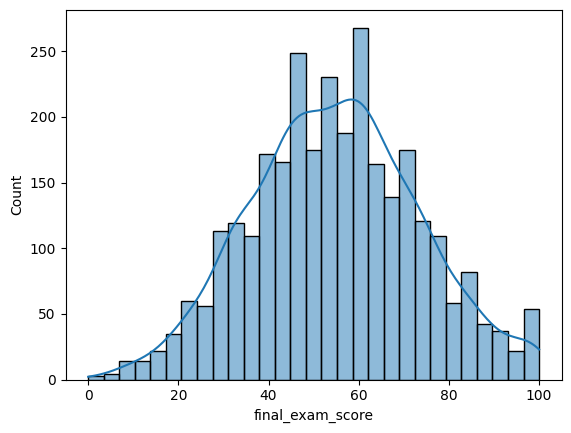

In [37]:
sns.histplot(df['final_exam_score'], kde=True)
plt.show()

✅ Approximately bell-shaped (normal distribution)

Most students scored between 40 and 70.
The peak is around 55–60.
As scores move away from the center, the number of students decreases.

✅ No severe skewness

The left and right sides are fairly balanced.
This is favorable for Linear Regression.

✅ No obvious extreme outliers

Scores range roughly from 0 to 100.
No isolated spikes far away from the rest of the data.

Step 4: Correlation Analysis


Linear Regression tries to find the relationship between input features (X) and the target variable (y = final_exam_score).
Correlation helps answer:
 Which features affect the exam score the most?

In the fig 
below :
Dark Red Mean : Positive Correlation(1.0)
Whit/Light Blue Mean : Little/light or None Correlation (0)
Blue Mean: Strong Negative Corelation(-1.0)

If you saw large dark red blocks outside the diagonal, it would mean two features are almost duplicates.
and there was no multicolinearity
    



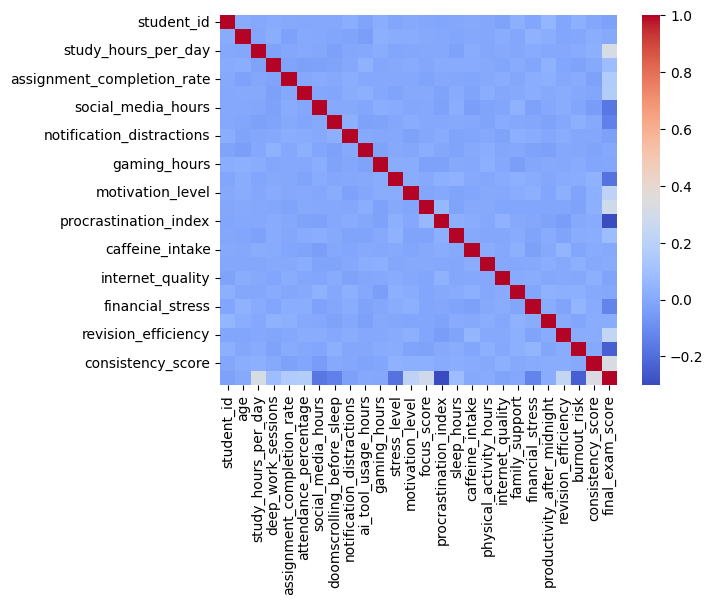

In [40]:
corr =df.select_dtypes(include='number').corr()
sns.heatmap(corr,cmap='coolwarm',)
plt.show()

In [42]:
df.corr(numeric_only=True)['final_exam_score'].sort_values(ascending=False)

final_exam_score               1.000000
consistency_score              0.329144
study_hours_per_day            0.317229
focus_score                    0.284073
revision_efficiency            0.230729
motivation_level               0.209093
attendance_percentage          0.172020
assignment_completion_rate     0.159037
deep_work_sessions             0.086185
sleep_hours                    0.081309
productivity_after_midnight    0.014107
physical_activity_hours        0.008024
caffeine_intake                0.000743
age                            0.000172
ai_tool_usage_hours           -0.003776
family_support                -0.004131
gaming_hours                  -0.010042
internet_quality              -0.018411
student_id                    -0.025445
notification_distractions     -0.031477
financial_stress              -0.127100
doomscrolling_before_sleep    -0.138240
social_media_hours            -0.170942
stress_level                  -0.186721
burnout_risk                  -0.239082


Step 5: Scatter Plot Analysis

Correlation tells you how strongly two variables are related


or 


features = [
    'study_hours_per_day',
    'focus_score',
    'consistency_score',
    'revision_efficiency'
]

for col in features:
    sns.scatterplot(x=df[col], y=df['final_exam_score'])
    plt.title(col)
    plt.show()

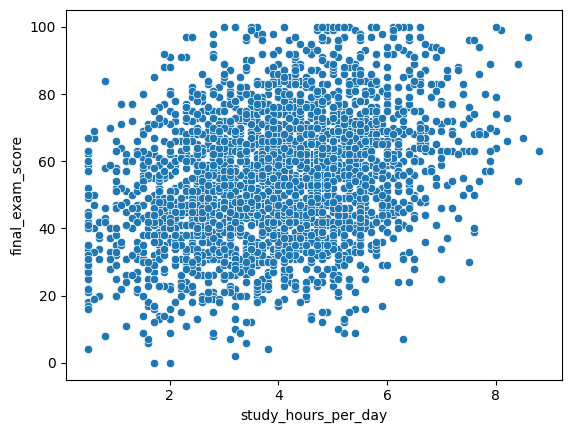

In [46]:
sns.scatterplot(x='study_hours_per_day', y='final_exam_score', data=df)

plt.show()

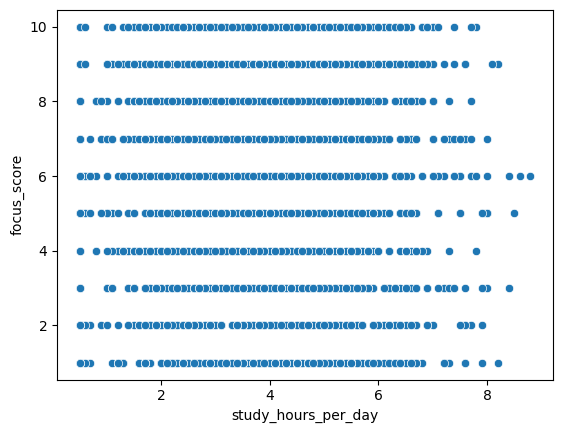

In [47]:
sns.scatterplot(x='study_hours_per_day', y='focus_score', data=df)
plt.show()

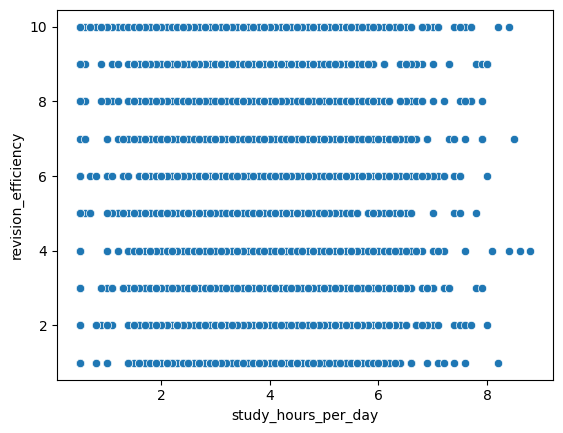

In [48]:
sns.scatterplot(x='study_hours_per_day', y='revision_efficiency', data=df)
plt.show()

Step 6: Outlier Detection
An outlier is a data point that differs significantly from the rest of the dataset, lying far away from the general pattern or trend.

Study Hours: 2, 3, 4, 5, 50
Score:      40,50,60,70,95

That student with 50 study hours is unusual and can distort the model.

in Fig:

ooo are outliers

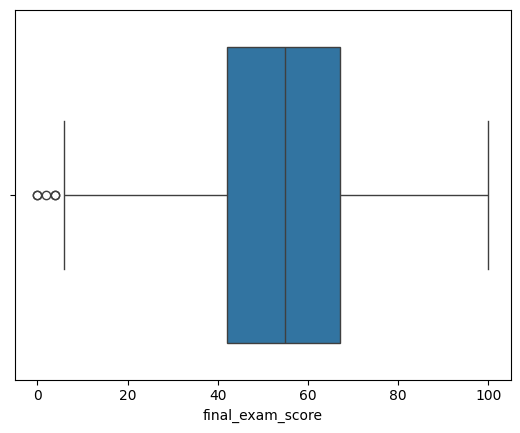

In [49]:
sns.boxplot(x=df['final_exam_score'])
plt.show()

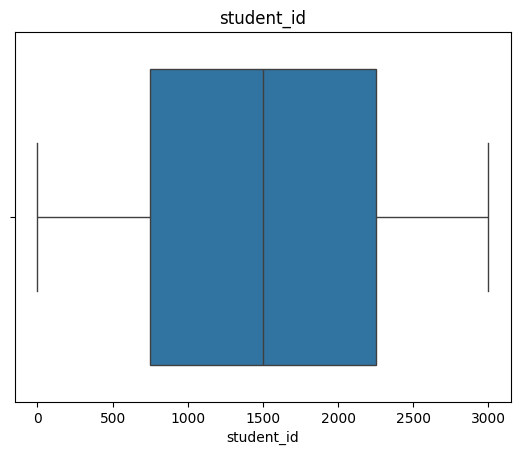

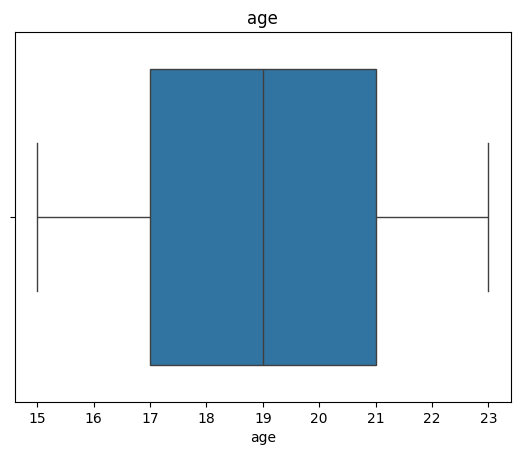

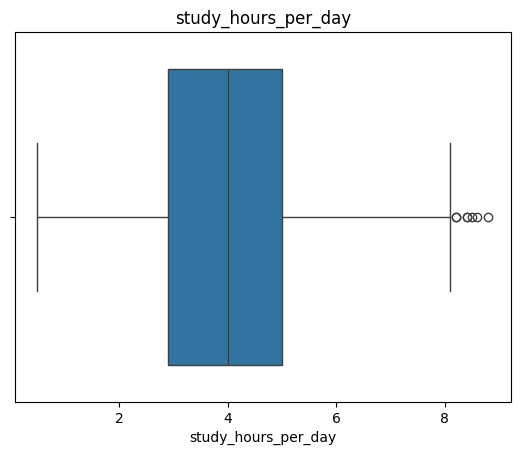

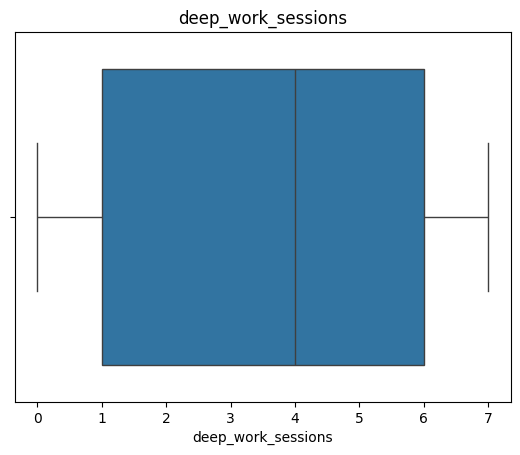

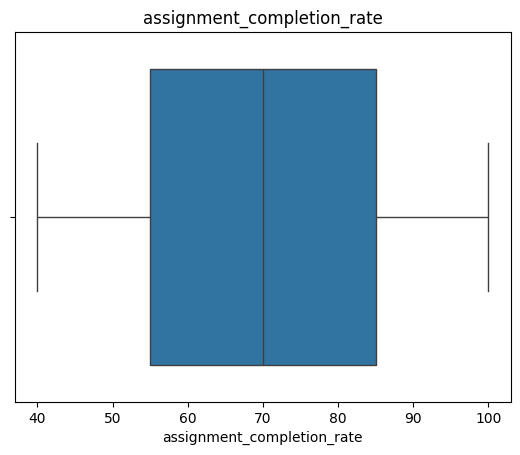

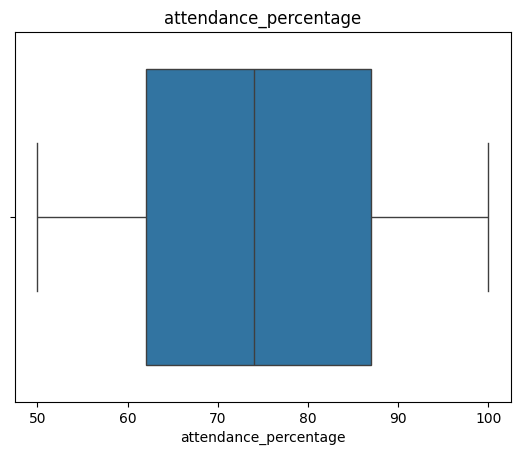

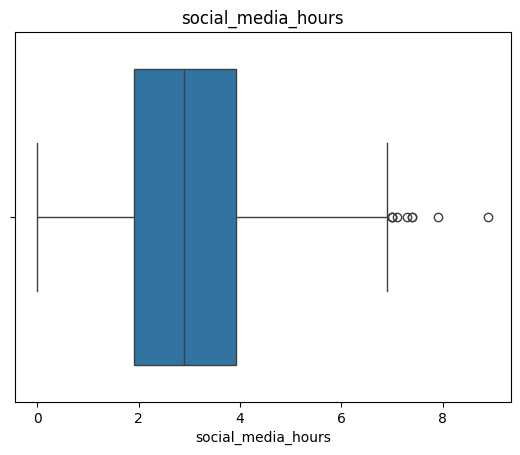

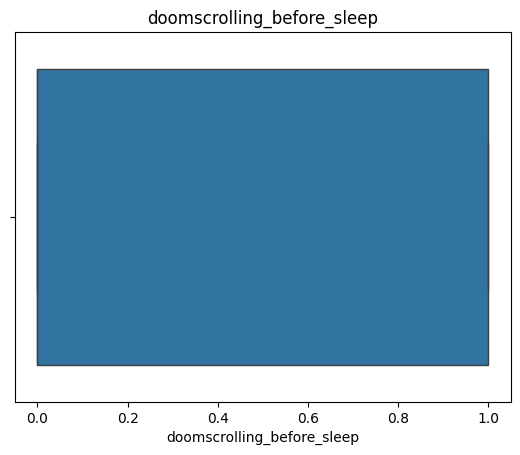

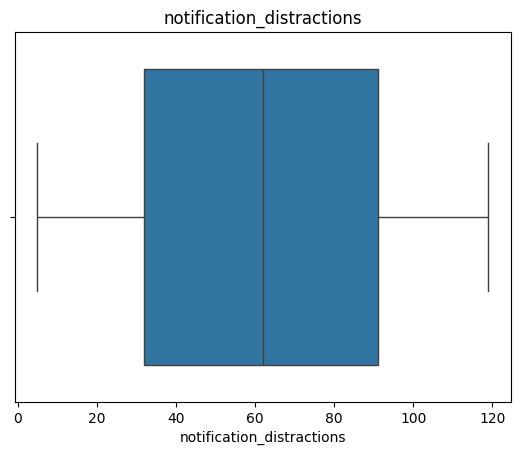

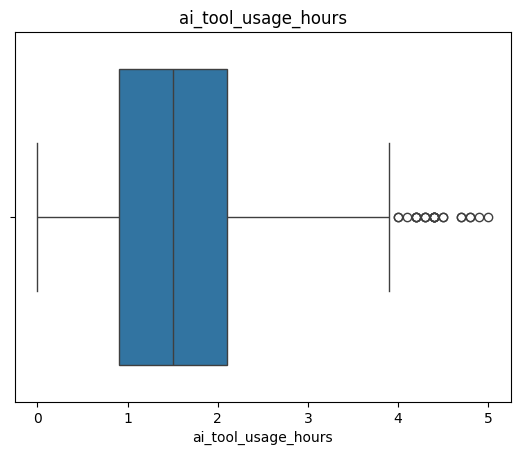

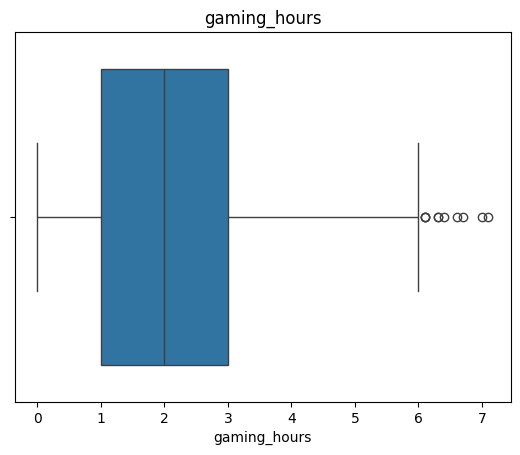

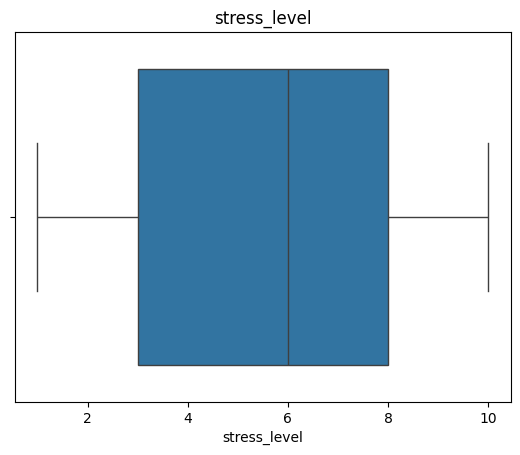

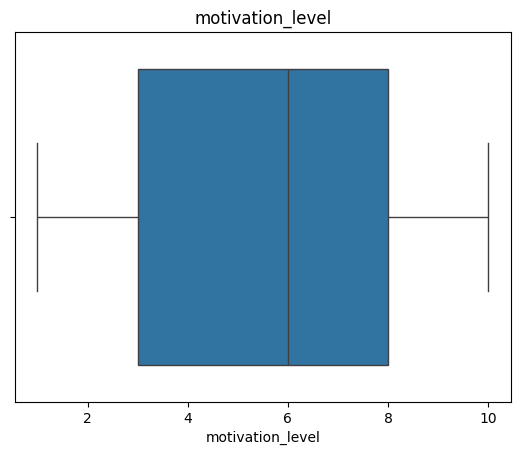

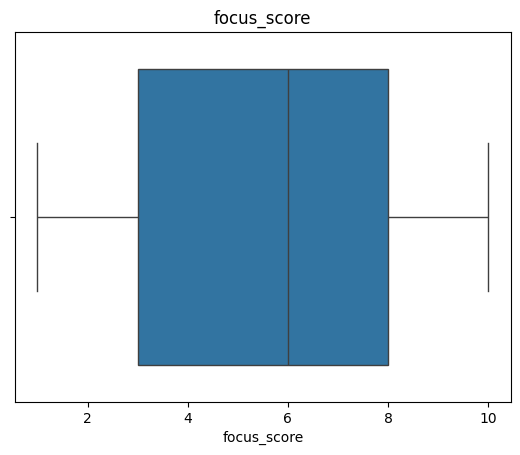

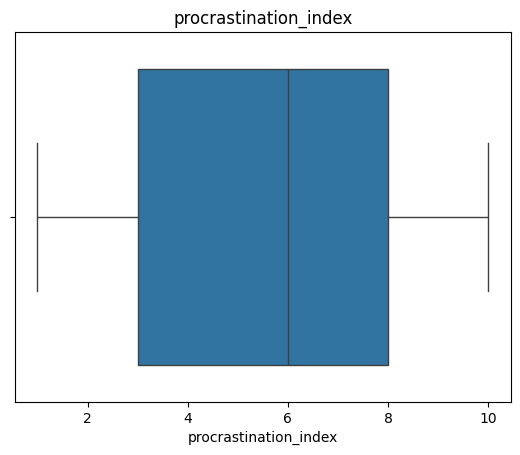

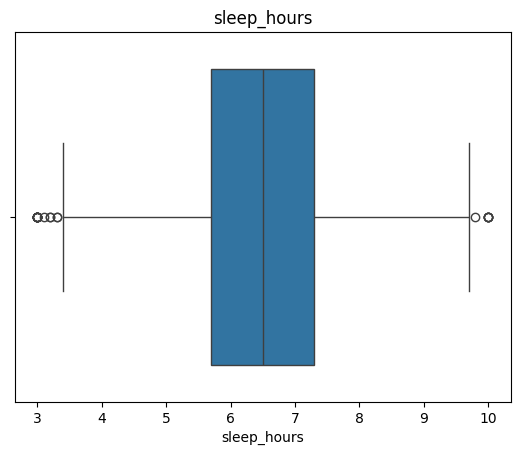

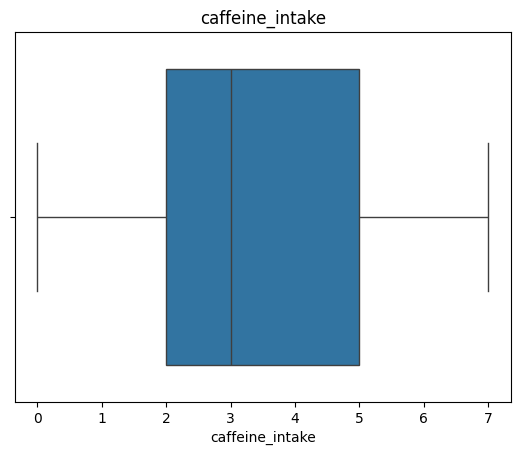

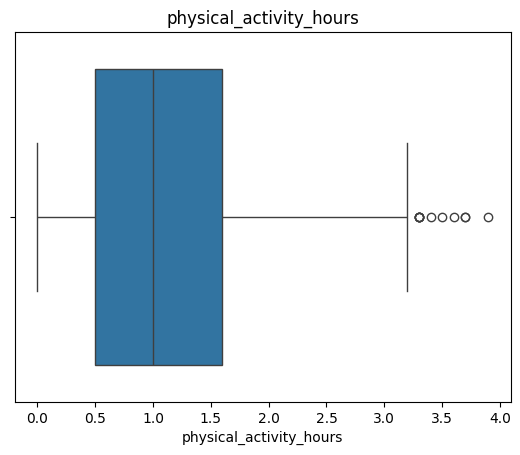

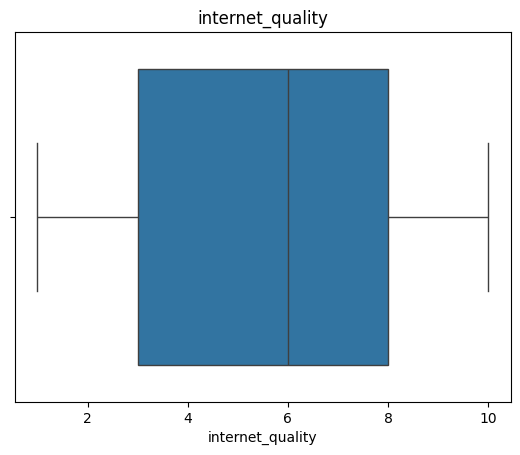

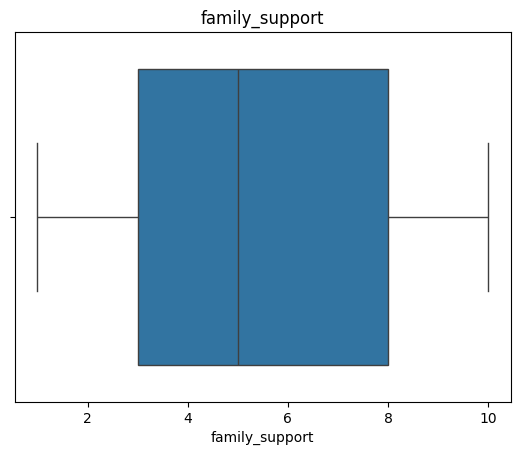

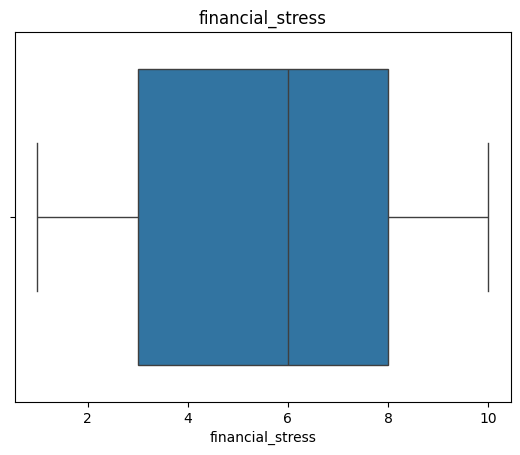

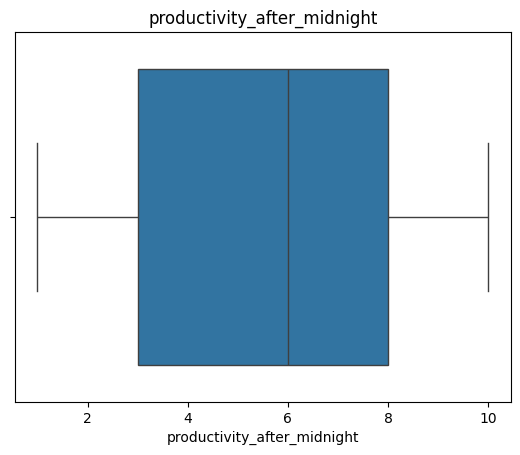

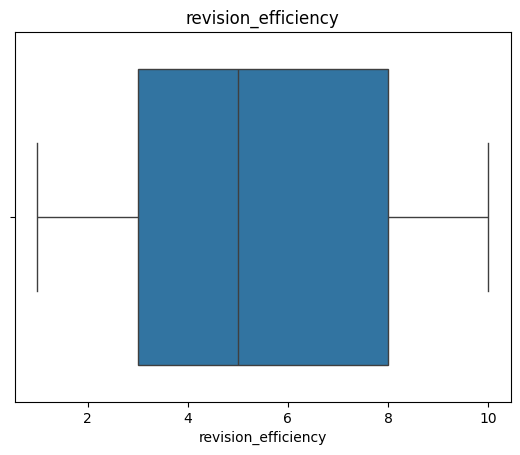

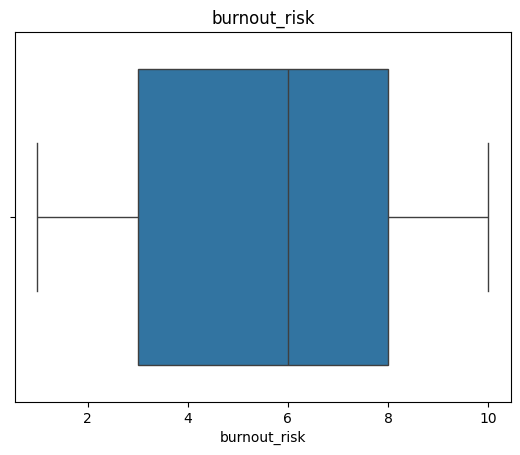

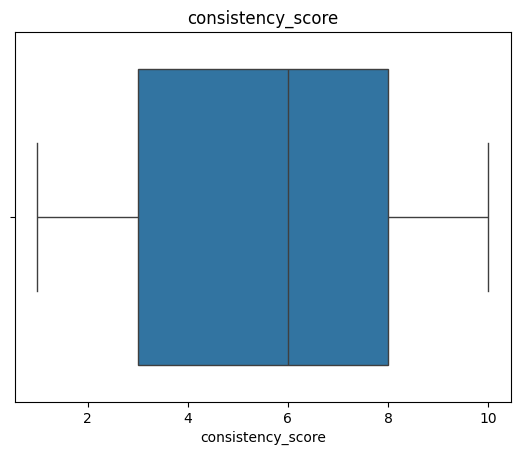

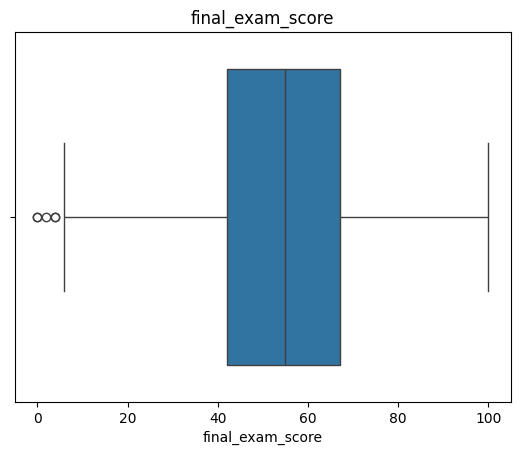

In [50]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Step 7: Categorical Variable Analysis
As u can see there are categorical var and ML gets better with numerical value pred

In [51]:
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [52]:
df.select_dtypes(include='object').columns

Index(['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal',
       'performance_category'],
      dtype='object')

In [ ]:
#this convert categorical variables into numerical format using one-hot encoding, which is essential for machine learning algorithms that require numerical input.
df = pd.get_dummies(
df,
  columns=[                 
     'gender',
        'city_type',
        'mental_state',
        'learning_style',
        'career_goal'

  ],
  drop_first=True
)

KeyError: "None of [Index(['gender', 'city_type', 'mental_state', 'learning_style', 'career_goal'], dtype='object')] are in the [columns]"

In [62]:
df.head()


,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,mental_state_Burnout,mental_state_Distracted,mental_state_Focused,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,0,21,3.2,7,100,70,3.8,0,107,0.6,...,False,False,False,False,False,False,False,True,False,False
1,1,19,3.9,2,46,70,2.6,1,93,1.5,...,True,False,False,True,False,False,True,False,False,False
2,2,16,4.3,7,54,57,4.3,1,82,0.5,...,True,False,False,False,False,True,False,True,False,False
3,3,19,5.3,1,78,90,1.7,0,27,1.4,...,True,False,False,False,True,False,False,False,True,False
4,4,17,4.1,3,100,81,2.6,0,8,1.3,...,False,False,True,False,False,True,False,False,True,False


In [63]:
df.select_dtypes(include='object').columns

Index(['performance_category'], dtype='object')

In [64]:
df = pd.get_dummies(
    df,
    columns=['performance_category'],
    drop_first=True
)

In [66]:
df=df.astype(int)
df

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,mental_state_Focused,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research,performance_category_Low,performance_category_Medium
0,0,21,3,7,100,70,3,0,107,0,...,0,0,0,0,0,1,0,0,1,0
1,1,19,3,2,46,70,2,1,93,1,...,0,1,0,0,1,0,0,0,0,1
2,2,16,4,7,54,57,4,1,82,0,...,0,0,0,1,0,1,0,0,1,0
3,3,19,5,1,78,90,1,0,27,1,...,0,0,1,0,0,0,1,0,0,1
4,4,17,4,3,100,81,2,0,8,1,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,22,2,0,40,83,1,0,71,2,...,0,1,0,0,0,0,0,0,1,0
2996,2996,19,5,7,94,100,1,0,114,3,...,0,0,0,1,0,0,1,0,0,0
2997,2997,23,5,2,41,86,5,1,88,0,...,0,1,0,0,0,1,0,0,0,1
2998,2998,17,3,1,92,96,2,1,94,1,...,1,1,0,0,0,0,1,0,0,0


Model Building

1. Define Features and Target

In [89]:
X=df.drop('final_exam_score',axis=1)
y=df['final_exam_score']

Split

In [90]:
# testing data would be 20% and training data would be 80%
#in trainig data : x_train, y_train will be used to train the model and 
# in testing data : x_test, y_test will be used to evaluate the model performance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

LinearRegression and modelfit

In [93]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Make Predictions

In [94]:
y_pred=model.predict

Evaluation

In [96]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error: 35.80607800510561
R2 Score: 0.8930480328892328


In [76]:
import numpy as np
rmse = np.sqrt(mse)
print(rmse)

5.98381801236515


In [81]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.8936075748993788
Test Score: 0.8930480328892328


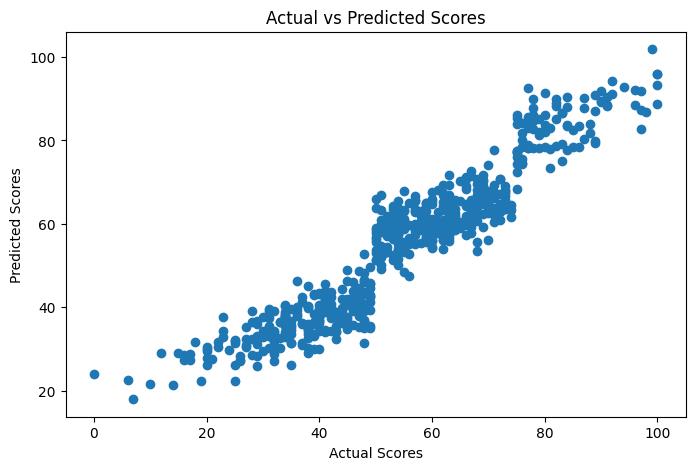

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()